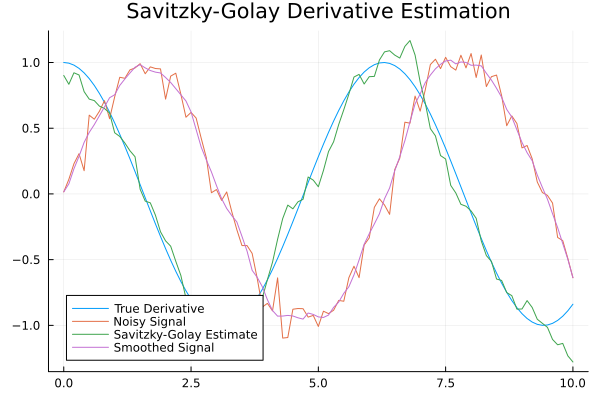

In [47]:
using SavitzkyGolay, Plots

# 1. Create noisy data (a sine wave)
t = 0:0.1:10
true_signal = sin.(t)
true_derivative = cos.(t)
noisy_signal = true_signal .+ 0.1 .* randn(length(t))

println("Noisy data generated", noisy_signal)

# 2. Apply the filter to get the derivative
#    window_size=11, polynomial_order=2, derivative_order=1
deriv_estimate = savitzky_golay(noisy_signal, 11, 2, deriv=1)
signal_estimate = savitzky_golay(noisy_signal, 11, 2, deriv=0)

h = Float64(t.step)
deriv_estimate_scaled = deriv_estimate.y ./ h

# deriv_estimate = savitzky_golay(noisy_signal, window_size=11, order=2, deriv=1)
println("Lengths - True: ", length(true_derivative), ", Estimate: ", length(deriv_estimate.y), "t: ", length(t))

# 3. Plot the results
plot(t, [true_derivative, noisy_signal, deriv_estimate_scaled, signal_estimate.y],
     label=["True Derivative" "Noisy Signal" "Savitzky-Golay Estimate" "Smoothed Signal"],
     title="Savitzky-Golay Derivative Estimation")




In [37]:
using SymbolicRegression

function run_symbolic_regression(X, y, options)
    hall_of_fame = equation_search(X, y; options=options, parallelism=:multithreading)

    dominating = calculate_pareto_frontier(hall_of_fame)
    return dominating
end

run_symbolic_regression (generic function with 1 method)

In [ ]:
options = SymbolicRegression.Options(;
    binary_operators=[+, *, /, -],
    unary_operators=[cos, exp], 
    should_optimize_constants=true,
    verbosity=0
)

t_matrix = hcat(t')
hall_of_fame = equation_search(t_matrix, deriv_estimate.y; options=options, parallelism=:multithreading)
dominating = calculate_pareto_frontier(hall_of_fame)

21-element Vector{PopMember{Float64, Float64, Expression{Float64, Node{Float64, 2}, @NamedTuple{operators::OperatorEnum{Tuple{Tuple{typeof(cos), typeof(exp)}, Tuple{typeof(+), typeof(*), typeof(/), typeof(-)}}}, variable_names::Vector{String}}}}}:
 PopMember(tree = (-0.0073543821149679445), loss = 0.005141404404363307, cost = 0.5141404404363307)
 PopMember(tree = (x1 * -0.0026032464116774855), loss = 0.00496846546268207, cost = 0.49684654626820696)
 PopMember(tree = (cos(x1) * 0.09842611318600718), loss = 9.968734576840774e-5, cost = 0.009968734576840775)
 PopMember(tree = ((cos(x1) * 0.09820968223489157) + -0.002147117527978161), loss = 9.510187175063229e-5, cost = 0.00951018717506323)
 PopMember(tree = (((x1 * 0.002273574529117231) + 0.08663493177265406) * cos(x1)), loss = 7.360640596513227e-5, cost = 0.007360640596513227)
 PopMember(tree = (((-0.028592064888943915 / exp(x1)) + 0.10192872919227995) * cos(x1)), loss = 7.160561585233887e-5, cost = 0.007160561585233887)
 PopMember(tree 

In [42]:
dominating[end]

PopMember(tree = (((-0.23910501381222496 / ((((cos(x1) * (x1 * 0.3717963464972676)) * cos(x1)) - -4.74312871566761) - cos(x1 + (cos(exp(cos(x1 + x1))) - -0.5233052728449321)))) + 0.13829384225206023) * cos(x1)), loss = 4.5750508862016964e-5, cost = 0.004575050886201696)

In [8]:
import RegularizationTools
using LinearAlgebra, Plots

# 1. Create noisy data and time vector
t = 0:0.05:10
h = t[2] - t[1] # Time step
true_signal = sin.(t)
true_derivative = cos.(t)
noisy_signal = true_signal .+ 0.1 .* randn(length(t))

# 2. Create the "integration" operator (a matrix)
A = Tridiagonal(fill(0.5, length(t)-1), fill(1.0, length(t)), fill(0.5, length(t)-1))
A = A * h

# 3. Find the derivative using Tikhonov regularization
#    This finds the 'x' (derivative) that minimizes ||Ax - y||² + λ||x||²
deriv_estimate = RegularizationTools.solve(A, noisy_signal, RegularizationTools.Tikhonov(1.0))

# 4. Plot
plot(t, [true_derivative, deriv_estimate],
     label=["True Derivative" "Tikhonov Estimate"],
     title="Tikhonov Regularization for Differentiation")

UndefVarError: UndefVarError: `Tikhonov` not defined in `RegularizationTools`
Suggestion: check for spelling errors or missing imports.